Adding physical features 

# Load Data

In [43]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from pandas.plotting import register_matplotlib_converters
from utils.data_loader import load_parquet
from sklearn.model_selection import TimeSeriesSplit, BaseCrossValidator
import numpy as np

# Load only specific columns needed for analysis
columns_needed = ['time', 'orbital_decay', '|avg B|', 'F10.7 (LASP)']

GFOC_data = load_parquet(columns=columns_needed)
print(GFOC_data.head())

✅ Successfully loaded data with shape: (3157920, 4)
                 time  orbital_decay   |avg B|  F10.7 (LASP)
0 2023-01-01 00:00:00        16.6730  5.630000         153.0
1 2023-01-01 00:00:20        16.6730  5.633333         153.0
2 2023-01-01 00:00:40        16.6735  5.636667         153.0
3 2023-01-01 00:01:00        16.6740  5.640000         153.0
4 2023-01-01 00:01:20        16.6740  5.633333         153.0


# 1. Select a subset

In [44]:
from utils.plot_loader import create_subset
# =========================== Input ===================================
start_date = '2024-04-26 00:00:00'
end_date = '2025-05-04 00:00:00'
# =====================================================================

subset = create_subset(GFOC_data, start_date, end_date, resample_rate='1min')

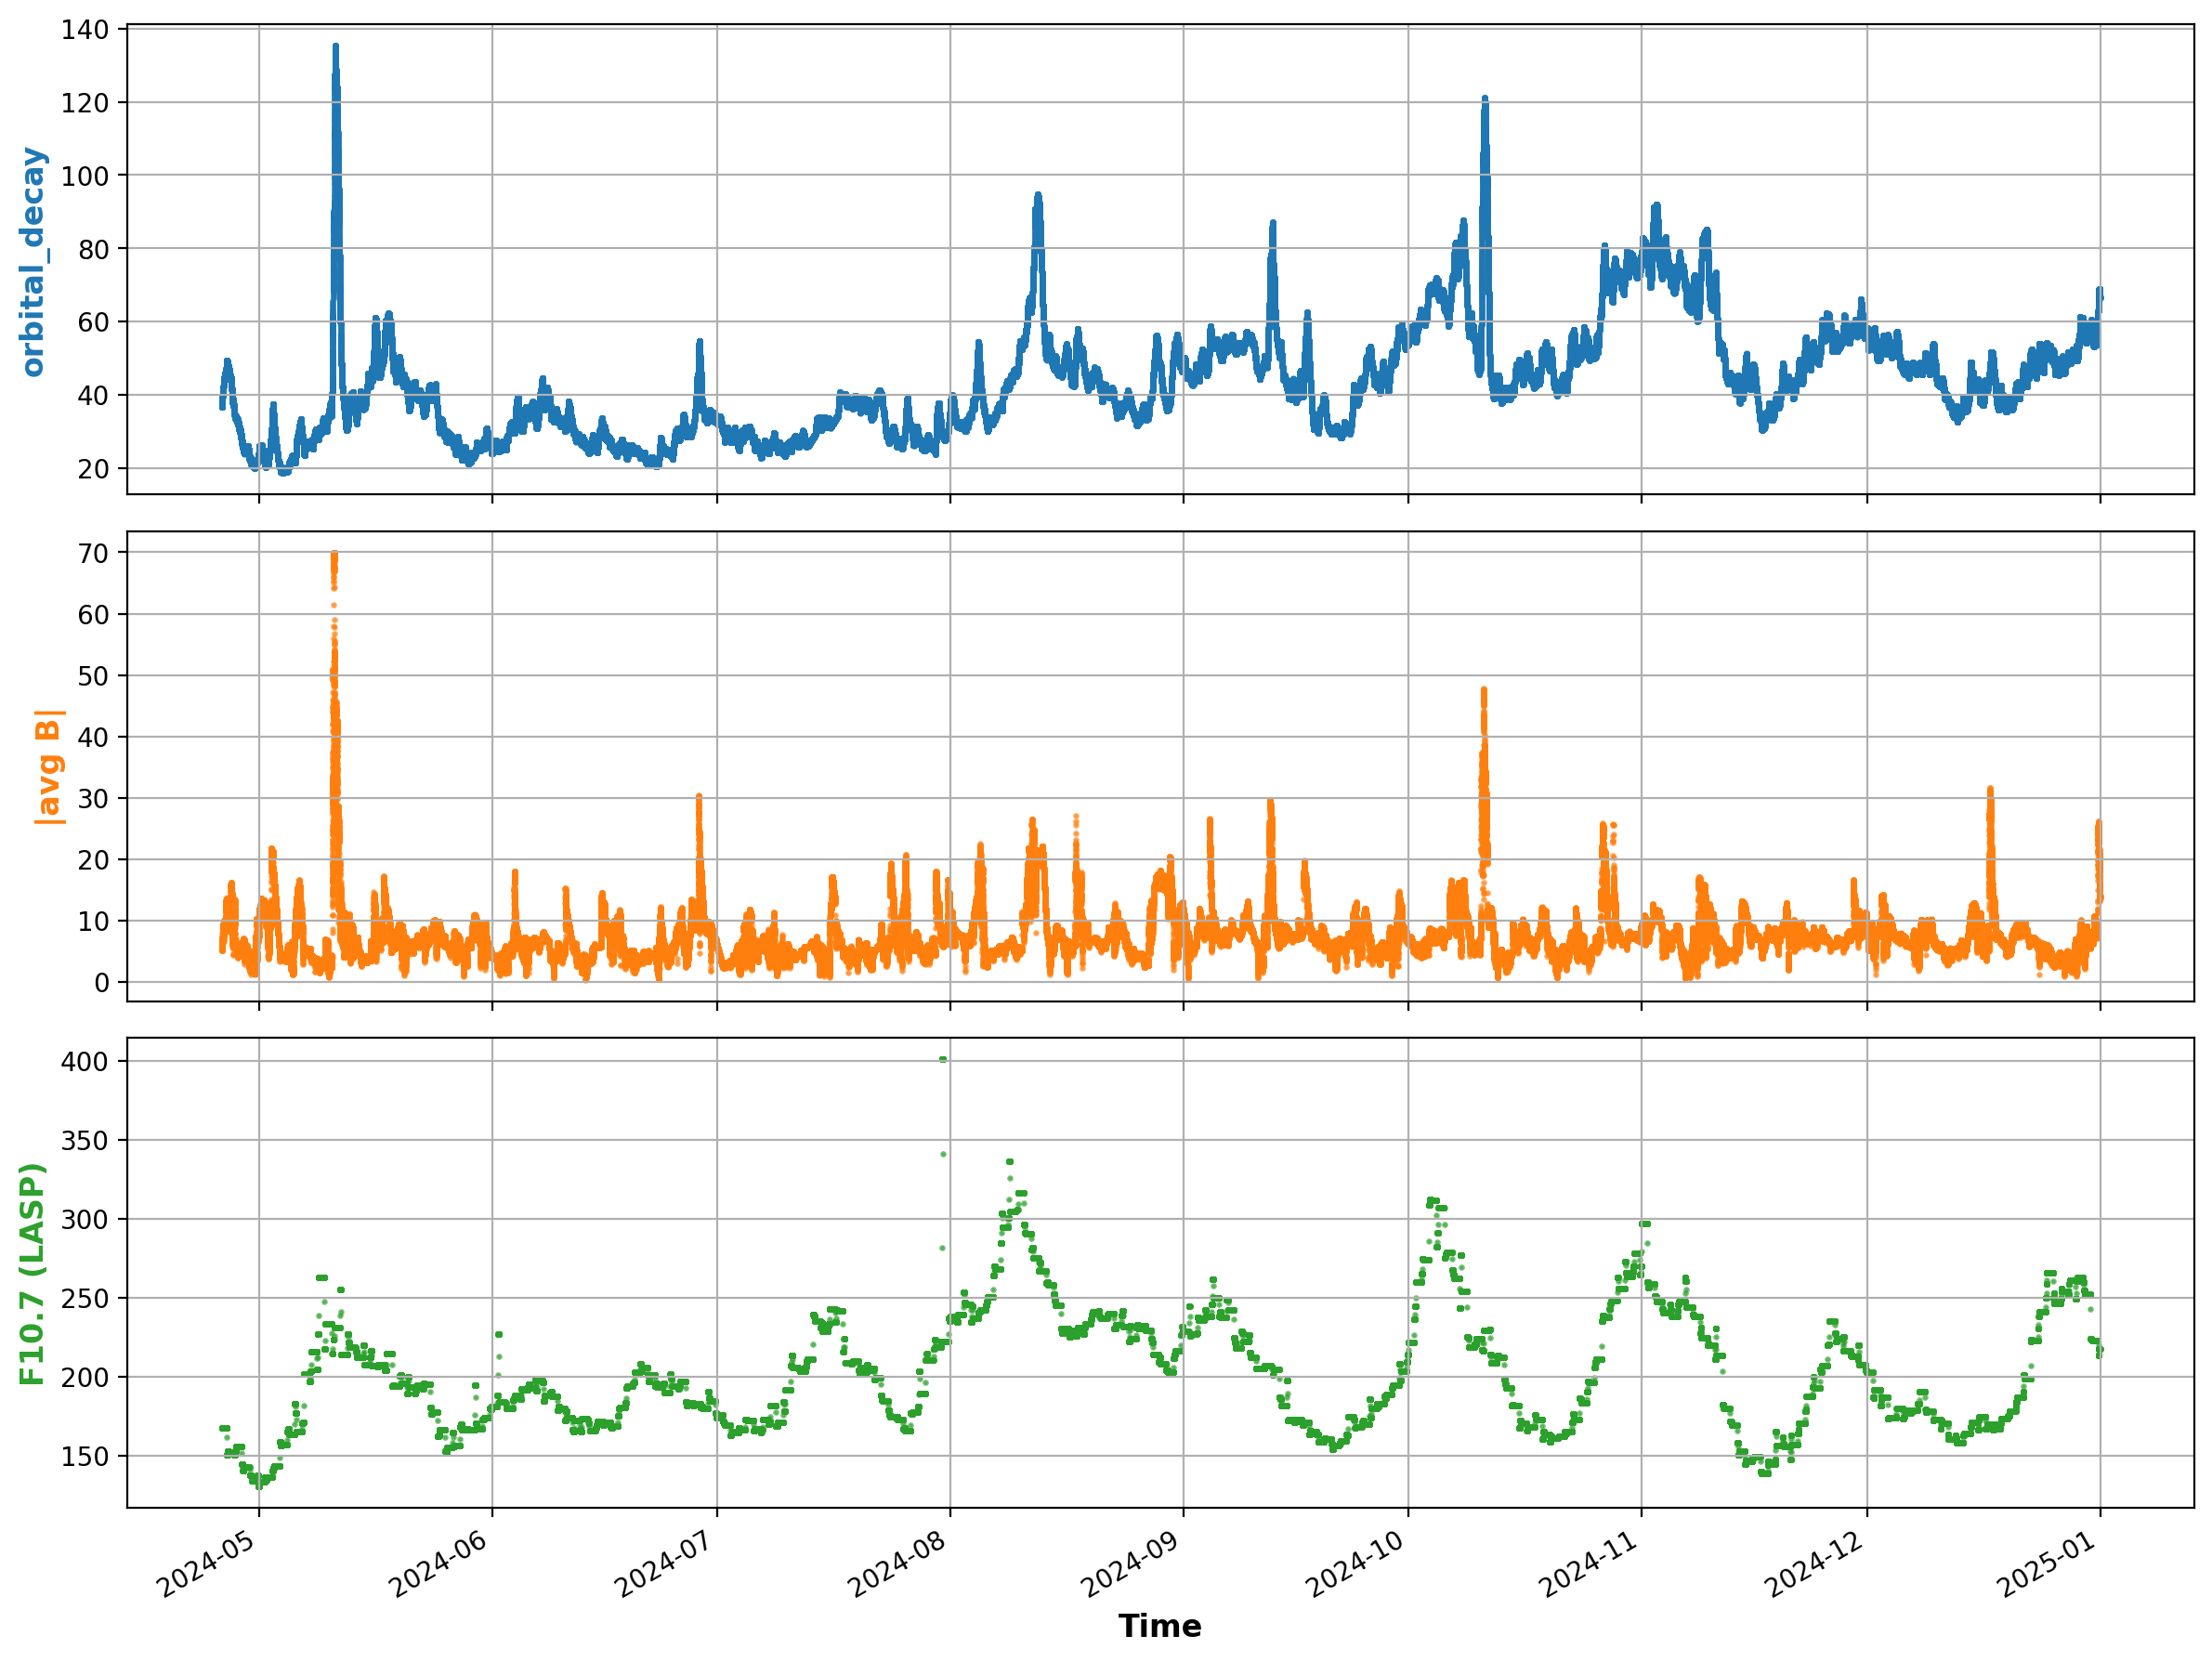

In [45]:
# plot all features from columns_needed
fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)

axes[0].scatter(subset.index, subset['orbital_decay'], s=2, c='C0', alpha=0.6)
axes[0].set_ylabel('orbital_decay', color='C0')
axes[0].grid(True)

axes[1].scatter(subset.index, subset['|avg B|'], s=2, c='C1', alpha=0.6)
axes[1].set_ylabel('|avg B|', color='C1')
axes[1].grid(True)

axes[2].scatter(subset.index, subset['F10.7 (LASP)'], s=2, c='C2', alpha=0.6)
axes[2].set_ylabel('F10.7 (LASP)', color='C2')
axes[2].set_xlabel('Time')
axes[2].grid(True)

fig.autofmt_xdate()
plt.tight_layout()
plt.show()

# 2. Prepare Data

In [46]:
def make_lags(df, lag_config, lead_time=1):
    out = {}

    for col, params in lag_config.items():
        n_lags = params.get('lags', 1)

        for i in n_lags:
            out[f"{col}_lag_{i}"] = df[col].shift(i)

    return pd.DataFrame(out)


def make_multistep_target(ts, steps):
    return pd.concat(
        {f'y_step_{i + 1}': ts.shift(-i)
         for i in range(steps)},
        axis=1)


In [47]:
lag_config = {
    'orbital_decay': {'lags': list(range(1, 24*60, 30)) + list(range(24*60, 2*24*60, 60))},      # (we want at least one full orbital period 100min)
    '|avg B|': {'lags': list(range(1, 12*60, 15)) + list(range(12*60, 24*60, 30)) + list(range(24*60, 2*24*60, 60))},            # (we want up to 50h)
    'F10.7 (LASP)': {'lags': list(range(1, 24*60, 90)) + list(range(24*60, 4*24*60, 180))}     # (changes very slowly, so few lags at long intervals are fine)
}

# from previous analysis, these lags were found to be most important
# orbital_decay_lags = [1, 2, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 117, 118, 119, 120, 121, 122, 123, 124, 210, 360, 405, 495, 780, 870, 960, 1020, 1110, 1200, 1290, 1350, 1440, 1620, 1680, 1860, 1920, 2100, 2280, 2340, 2520, 2700, 2760]
# avgB_lags = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 59, 60, 99, 100, 104]
# f10_lags = [2]

# lag_config = {
#     'orbital_decay': {'lags': orbital_decay_lags},
#     '|avg B|': {'lags': avgB_lags},
#     'F10.7 (LASP)': {'lags': f10_lags}
# }

X = make_lags(subset, lag_config)

# n hour forecast (1 minute intervals) for each point
n = 3
y = make_multistep_target(subset[['orbital_decay']].copy(), steps=n * 60)

# Shifting has created indexes that don't match. Only keep times for
na_mask = X.isna().any(axis=1) | y.isna().any(axis=1)
X = X[~na_mask]
y = y[~na_mask]

# Rename columns to avoid MultiIndex issues
X.columns = ['_'.join(map(str, col)) if isinstance(col, tuple) else str(col) for col in X.columns]

## Feature validation

<Axes: >

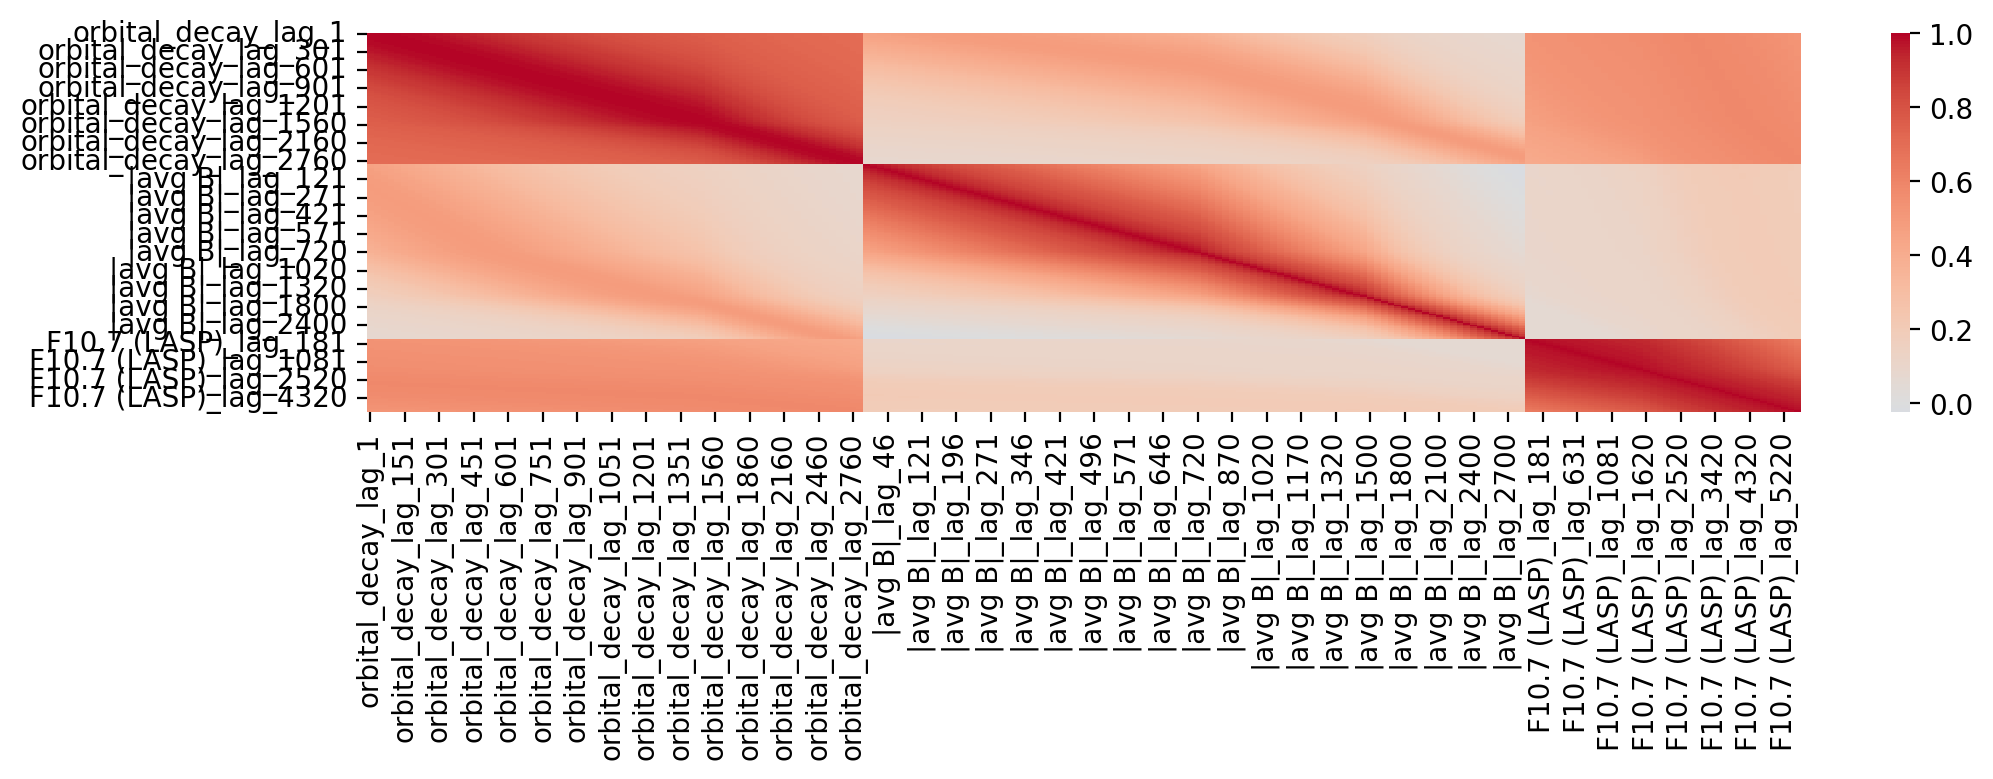

In [48]:
import seaborn as sns

corr = X.corr()
sns.heatmap(corr, cmap='coolwarm', center=0)

In [49]:
corr_scores = X.corrwith(y.iloc[:, 0])  # e.g., first horizon
top_features = corr_scores.abs().sort_values(ascending=False).head(40).index
X_filtered = X[top_features]

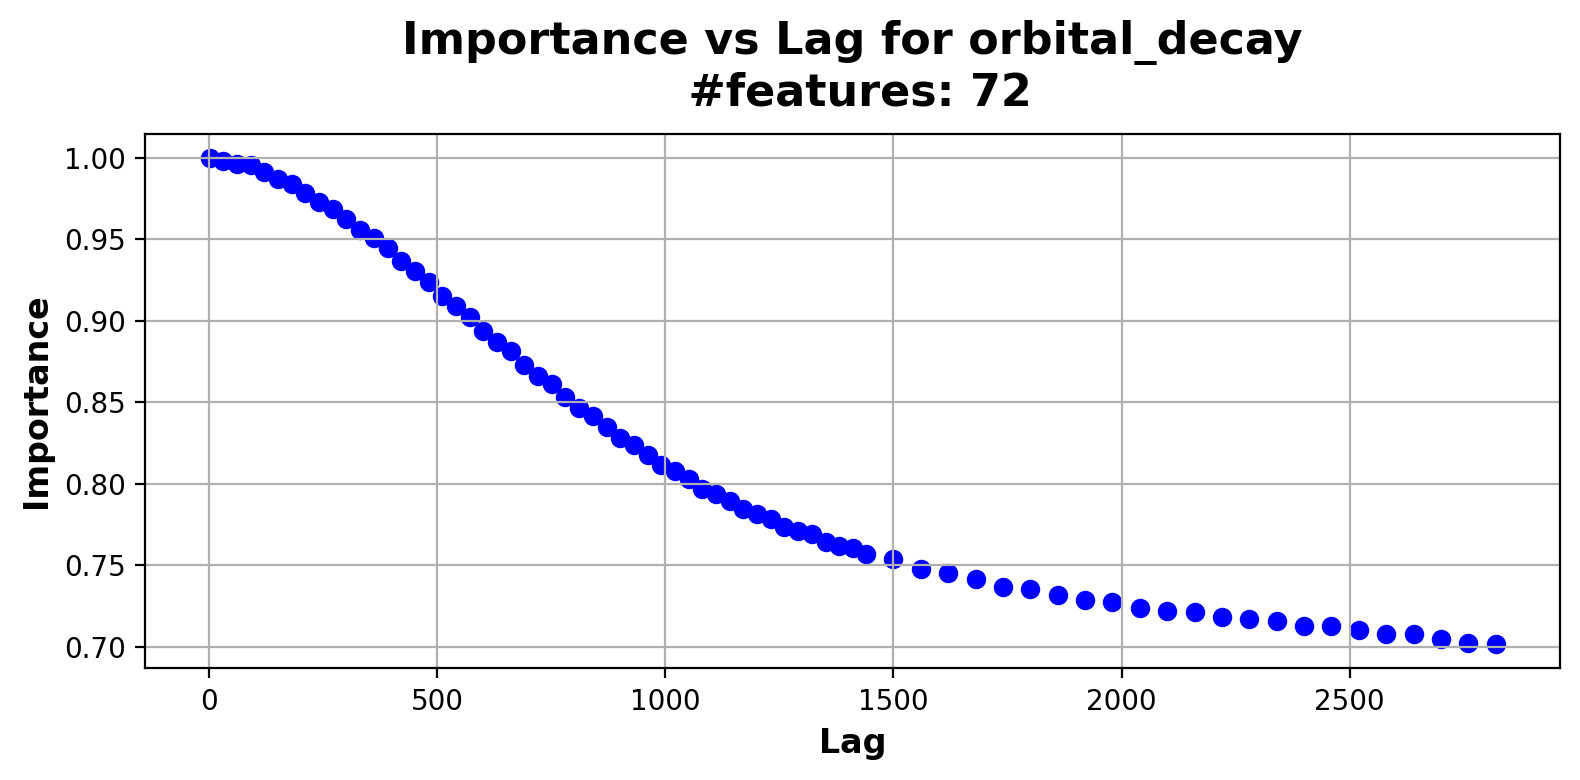

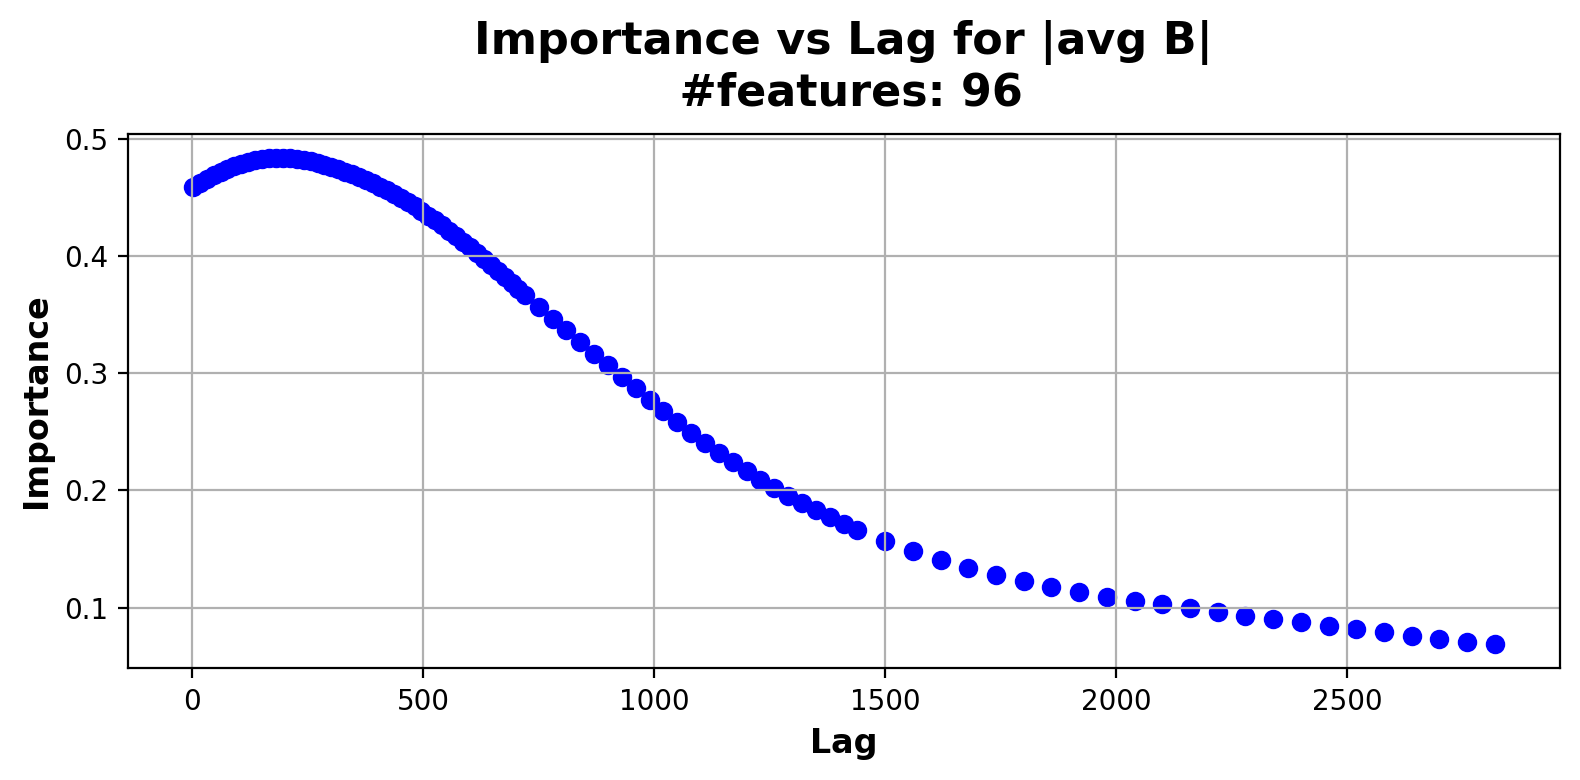

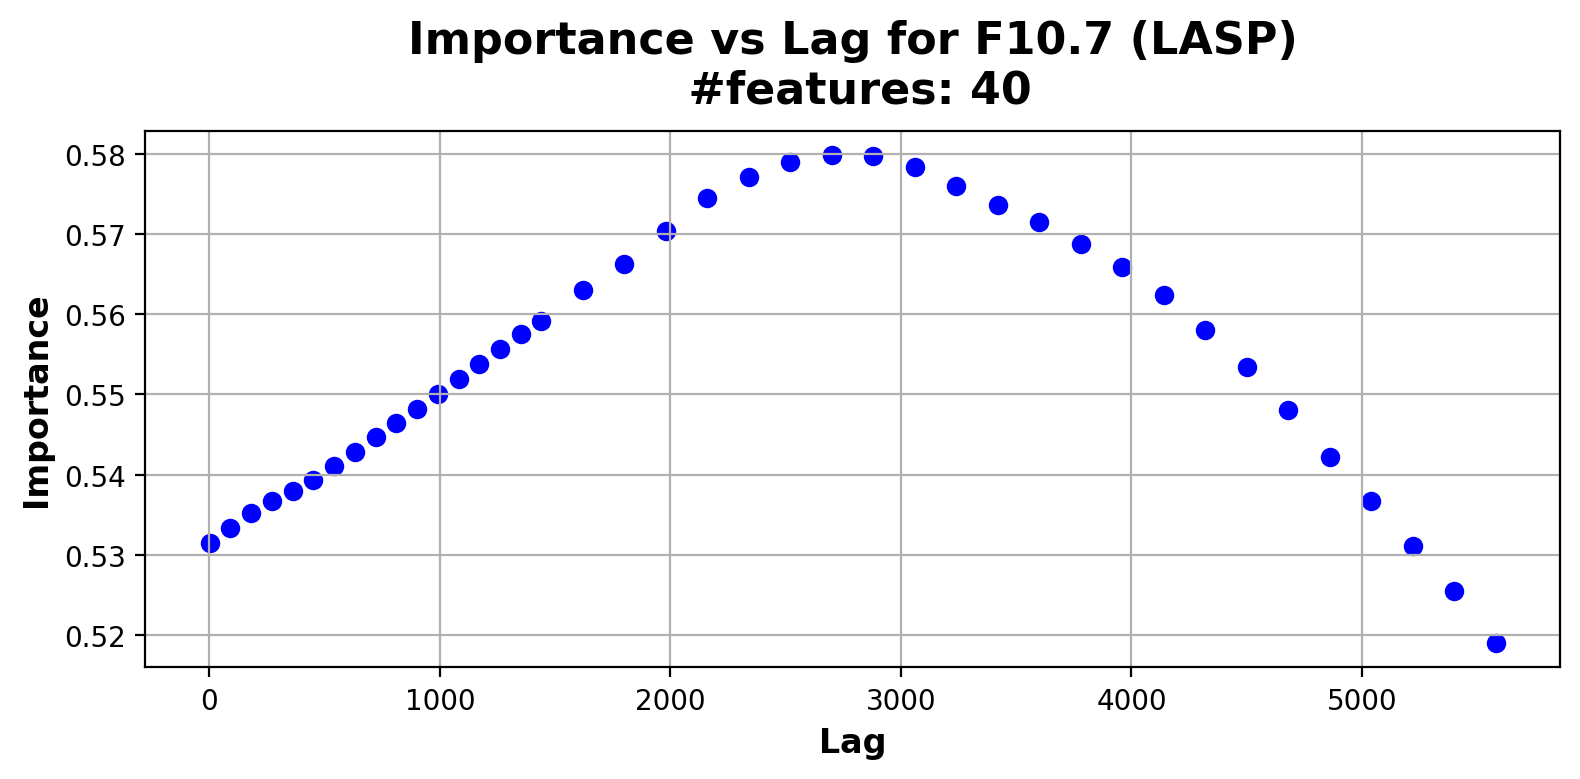

In [50]:
import re

# Example: feature_consistency is a pandas Series
# feature_consistency = pd.Series(...)

# Filter features by importance threshold
filtered = corr_scores

# Extract feature names and lags
feature_names = []
lags = []

for feat in filtered.index:
    match = re.match(r"(.+)_lag_(\d+)", feat)
    if match:
        feature_names.append(match[1])
        lags.append(int(match[2]))
    else:
        feature_names.append(feat)
        lags.append(0)

# Build a DataFrame
df_F = pd.DataFrame({
    'feature': feature_names,
    'lag': lags,
    'importance': filtered.values
})

# Plot each feature separately
features_to_plot = df_F['feature'].unique()

for feature in features_to_plot:
    df_feat = df_F[df_F['feature'] == feature]
    plt.figure(figsize=(8, 4))
    plt.scatter(df_feat['lag'], df_feat['importance'], color='blue')
    plt.title(f"Importance vs Lag for {feature}\n #features: {len(df_feat)}")
    plt.xlabel("Lag")
    plt.ylabel("Importance")
    plt.grid(True)
    plt.show()


# 3. Multioutput Model

### split into two sets

In [51]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Train-test split (chronologically)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

model = LinearRegression()
model.fit(X_train, y_train)

y_fit = pd.DataFrame(model.predict(X_train), index=X_train.index, columns=y.columns)
y_pred = pd.DataFrame(model.predict(X_test), index=X_test.index, columns=y.columns)

### multisplit

In [52]:
class FixedRollingSplit(BaseCrossValidator):
    def __init__(self, train_size, n_splits=None, step=None, test_size=None, fixed_test_to_end=False, start=0):
        self.n_splits = n_splits
        self.train_size = train_size
        self.test_size = test_size
        self.step = step or test_size
        self.fixed_test_to_end = fixed_test_to_end
        self.start = start

    def split(self, X, y=None, groups=None):
        n_samples = len(X)
        start = self.start
        if self.n_splits is None:
            self.n_splits = n_samples // self.step

        if self.test_size is None:
            self.test_size = n_samples - self.train_size - start

        if start + self.train_size + self.test_size > n_samples:
            raise ValueError(f"Train size + test size + start must be less than the number of samples ({n_samples}). train : {self.train_size}, test : {self.test_size}, start : {start}, n_samples : {n_samples})")

        actual_n_splits = 0
        for i in range(self.n_splits):
            if start + self.train_size > n_samples:
                actual_n_splits = i
                break

            train_start = start
            train_end = train_start + self.train_size

            if not self.fixed_test_to_end:
                test_start = train_end
                test_end = test_start + self.test_size
            else:
                test_start = n_samples - self.test_size
                test_end = n_samples

            if (test_start < train_end) or (test_end > n_samples):
                actual_n_splits = i
                break

            yield np.arange(train_start, train_end), np.arange(test_start, test_end)
            start += self.step
            actual_n_splits += 1

        self.n_splits = actual_n_splits

    def get_n_splits(self, x=None, y=None, groups=None):
        return self.n_splits

In [53]:
train_size, test_size = 5*24*60, 3*60
splitter = FixedRollingSplit(train_size=train_size,
                             test_size=test_size,
                             step=test_size,
                             start=15*60)
splits = list(splitter.split(X, y))

train_idx, test_idx = splits[0]
X_train, X_test = X.iloc[train_idx].copy(), X.iloc[test_idx].copy()
y_train, y_test = y.iloc[train_idx].copy(), y.iloc[test_idx].copy()

In [54]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, y_train)

y_fit = pd.DataFrame(model.predict(X_train), index=X_train.index, columns=y.columns)
y_pred = pd.DataFrame(model.predict(X_test), index=X_test.index, columns=y.columns)

In [55]:
# from sklearn.pipeline import make_pipeline
# from sklearn.preprocessing import StandardScaler
# from sklearn.linear_model import MultiTaskLasso

# pipeline = make_pipeline(
#     StandardScaler(),
#     MultiTaskLasso(alpha=0.1, warm_start=True, max_iter=500)
# )

# pipeline.fit(X_train, y_train)

# lasso = pipeline.named_steps["multitasklasso"]
# print(f'Number of non-zero coefficients: {np.sum(lasso.coef_ != 0)} out of {len(lasso.coef_)}')

In [56]:
# feature_strength = np.abs(lasso.coef_).sum(axis=0)
# feature_strength = (feature_strength > 0).astype(int)
# print(sum(feature_strength))
# # save as csv
# # pd.DataFrame({'feature': X.columns, 'importance': feature_strength}).to_csv('feature_importance.csv', index=False)

### Sanity check

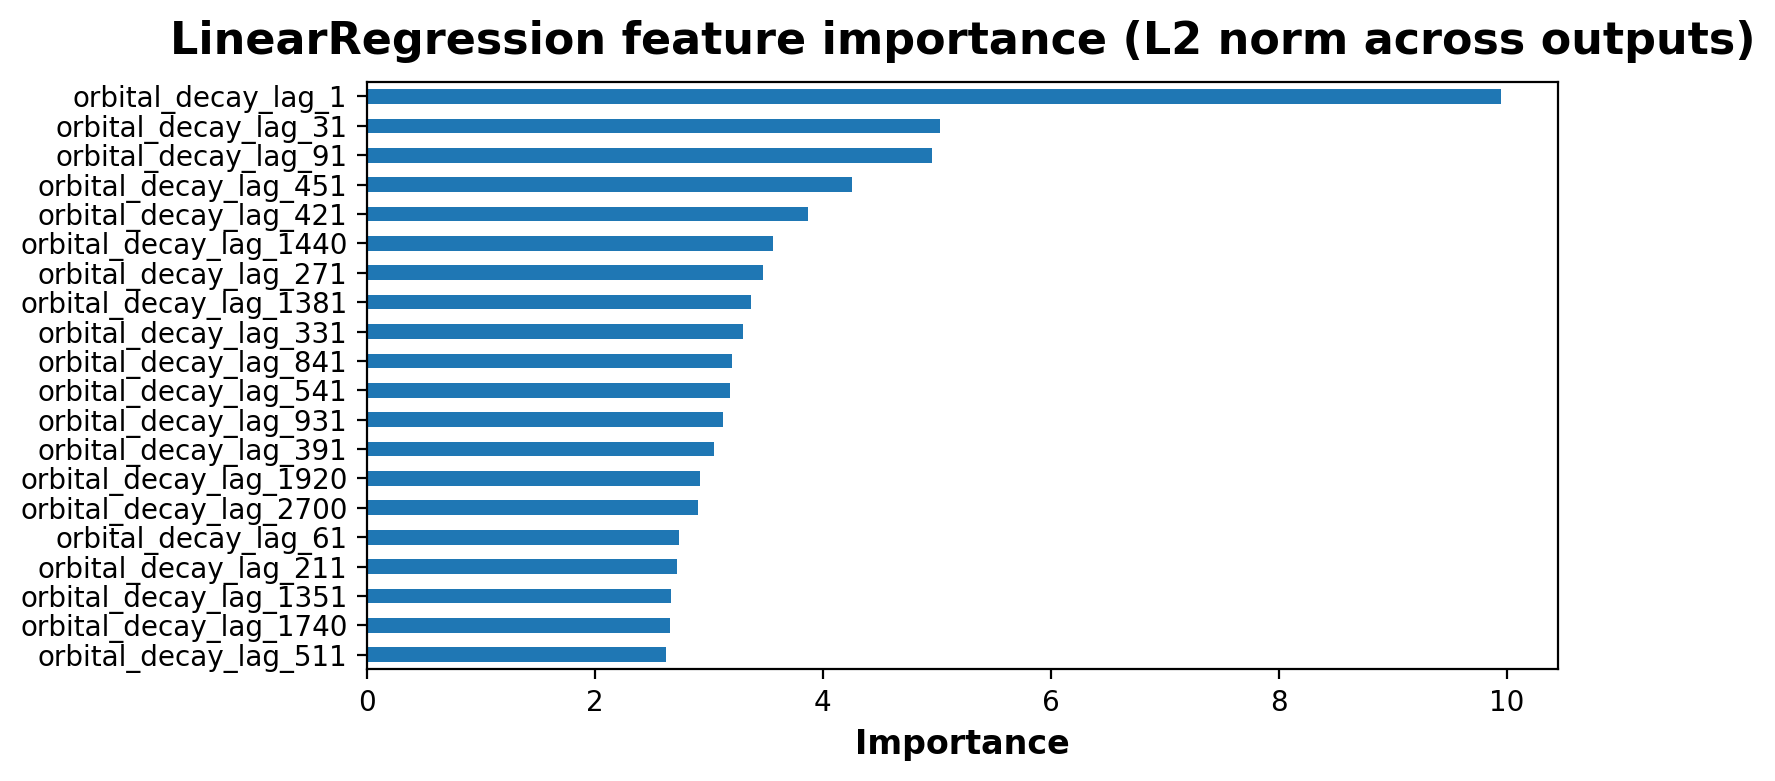

In [57]:
import numpy as np
import pandas as pd

# Feature importance for LinearRegression (handles multioutput)

# get coefficients (supports plain LinearRegression or MultiOutputRegressor-like wrappers)
if hasattr(model, "coef_"):
    coefs = model.coef_
elif hasattr(model, "estimators_"):
    # stack coefficients from wrapped estimators (e.g. MultiOutputRegressor)
    coefs = np.vstack([getattr(est, "coef_", np.zeros(len(X.columns))) for est in model.estimators_])
else:
    raise RuntimeError("Model does not expose coefficients via coef_ or estimators_")

# aggregate importance across outputs: use L2 norm across target dims
if coefs.ndim == 1:
    importance = np.abs(coefs)
else:
    importance = np.linalg.norm(coefs, axis=0)

imp_series = pd.Series(importance, index=X.columns).sort_values()

# only plot the top 20 features
imp_series = imp_series.tail(20)

fig, ax = plt.subplots(figsize=(8, max(4, len(imp_series) * 0.02)))
imp_series.plot.barh(ax=ax, color="C0")
ax.set_title("LinearRegression feature importance (L2 norm across outputs)")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.show()

Save model

In [58]:
# model_10_20 = model

## Results

In [59]:
from warnings import simplefilter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

simplefilter("ignore")

# Set Matplotlib defaults
plt.style.use("default")
plt.rc("figure", autolayout=True, figsize=(11, 4))
plt.rc(
    "axes",
    labelweight="bold",
    labelsize="large",
    titleweight="bold",
    titlesize=16,
    titlepad=10,
)
plot_params = dict(
    color="0.75",
    style=".-",
    markeredgecolor="0.25",
    markerfacecolor="0.25",
)
%config InlineBackend.figure_format = 'retina'


def plot_multistep(y, every=1, ax=None, palette_kwargs=None):
    palette_kwargs_ = dict(palette='husl', n_colors=16, desat=None)
    if palette_kwargs is not None:
        palette_kwargs_.update(palette_kwargs)
    palette = sns.color_palette(**palette_kwargs_)
    if ax is None:
        fig, ax = plt.subplots()
    ax.set_prop_cycle(plt.cycler('color', palette))
    for date, preds in y[::every].iterrows():
        preds.index = pd.period_range(start=date, periods=len(preds), freq='60S')
        preds.plot(ax=ax, alpha=0.5)
    return ax

## Results

In [60]:
from sklearn.metrics import root_mean_squared_error
from sklearn.metrics import r2_score

train_rmse = root_mean_squared_error(y_train, y_fit)
test_rmse = root_mean_squared_error(y_test, y_pred)
print((f"Train RMSE: {train_rmse:.3}\n" f"Test RMSE: {test_rmse:.3}"))
train_r2 = r2_score(y_train, y_fit)
test_r2 = r2_score(y_test, y_pred)
print((f"Train R2: {train_r2:.3}\n" f"Test R2: {test_r2:.3}"))

Train RMSE: 0.155
Test RMSE: 0.559
Train R2: 0.998
Test R2: -3.16


### Evolution of Error

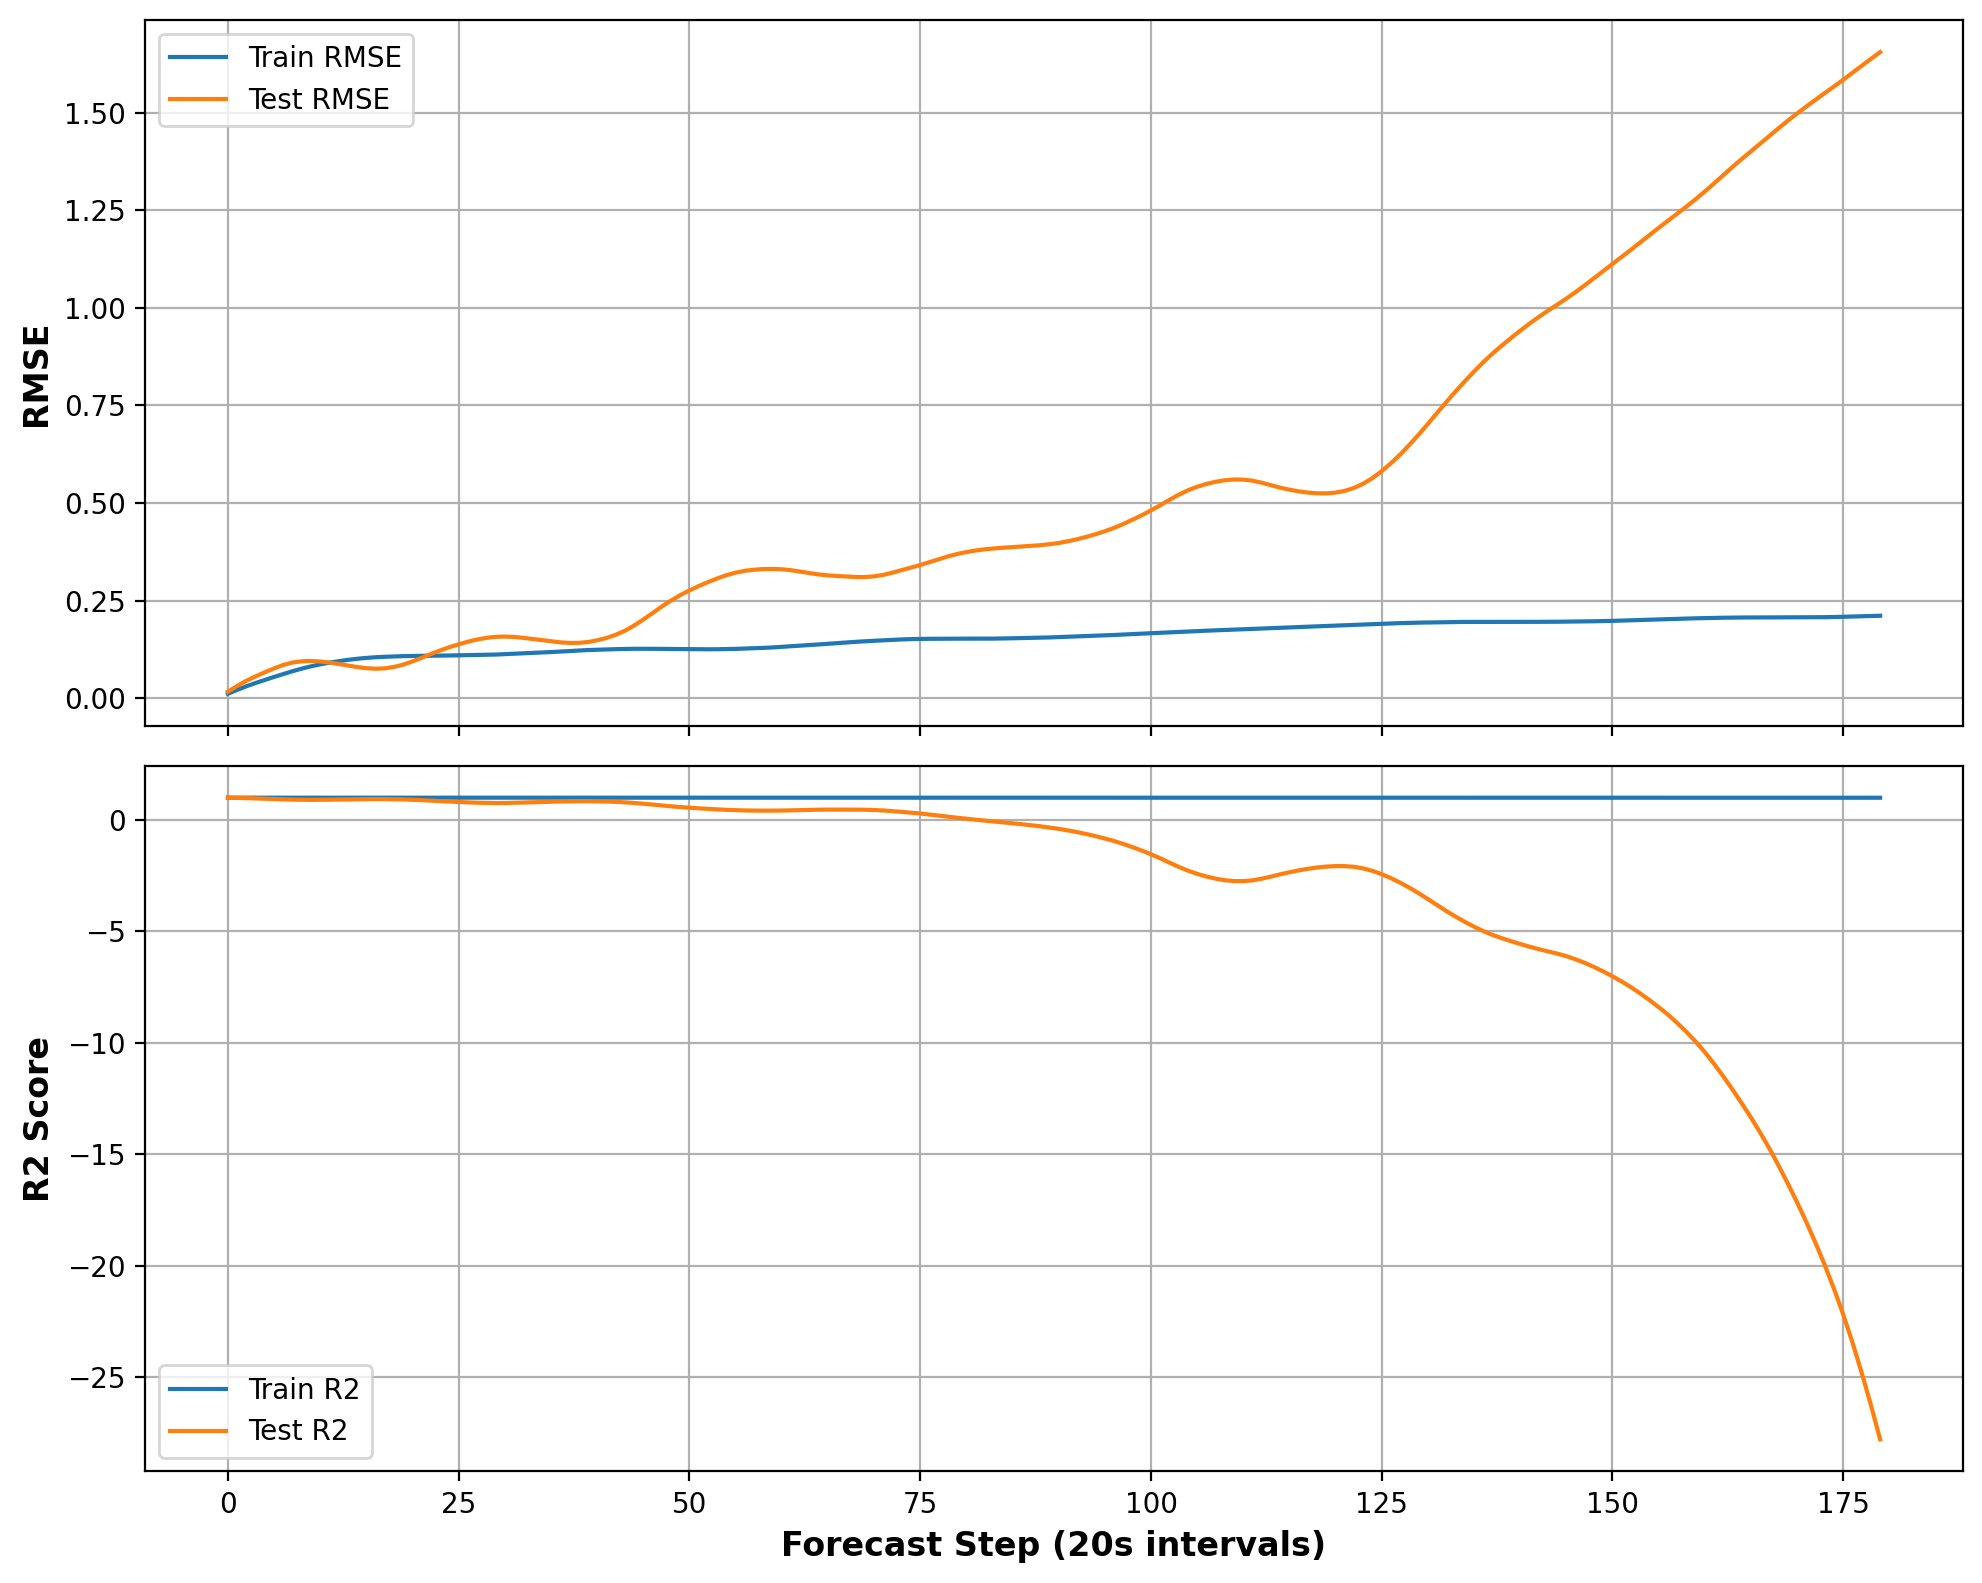

In [61]:
train_rmse_list = []
test_rmse_list = []
train_r2_list = []
test_r2_list = []

for i in range(len(y.columns)):
    train_rmse_list.append(root_mean_squared_error(y_train.iloc[:, i], y_fit.iloc[:, i]))
    test_rmse_list.append(root_mean_squared_error(y_test.iloc[:, i], y_pred.iloc[:, i]))
    train_r2_list.append(r2_score(y_train.iloc[:, i], y_fit.iloc[:, i]))
    test_r2_list.append(r2_score(y_test.iloc[:, i], y_pred.iloc[:, i]))

fix, ax = plt.subplots(2, 1, figsize=(10, 8), sharex=True)
ax[0].plot(train_rmse_list, label='Train RMSE')
ax[0].plot(test_rmse_list, label='Test RMSE')
ax[0].set_ylabel('RMSE')
ax[0].legend()
ax[0].grid(True)

ax[1].plot(train_r2_list, label='Train R2')
ax[1].plot(test_r2_list, label='Test R2')
ax[1].set_ylabel('R2 Score')
ax[1].set_xlabel('Forecast Step (20s intervals)')
ax[1].legend()
ax[1].grid(True)
plt.tight_layout()
plt.show()

## Plot

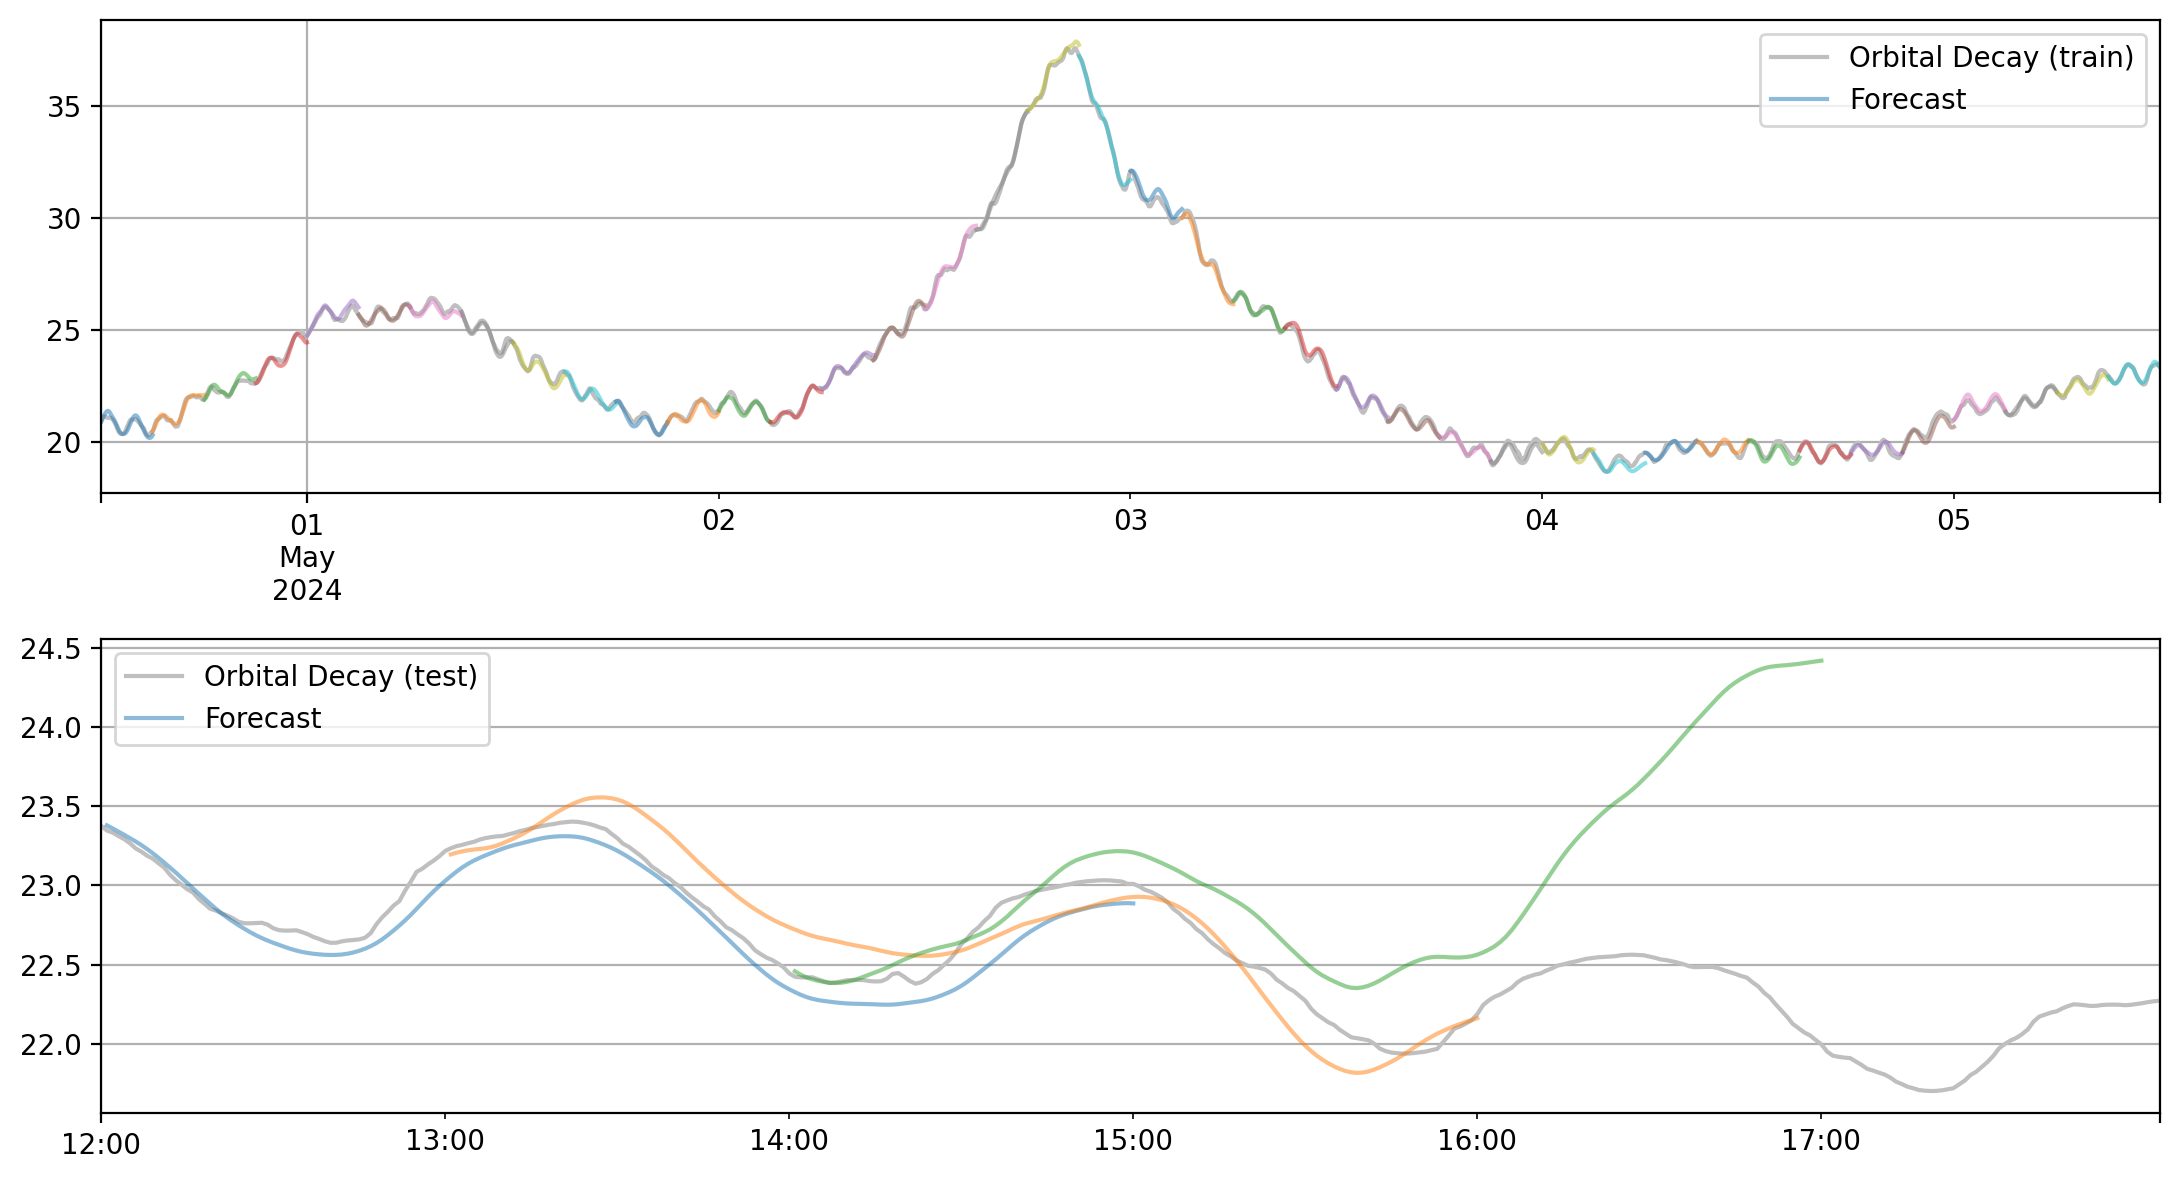

In [70]:

palette = dict(palette='husl', n_colors=64)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 6))
ax1 = y_train.iloc[:,[0]].plot(**plot_params, ax=ax1)
ax1 = plot_multistep(y_fit, every=180, ax=ax1, palette_kwargs=palette)
_ = ax1.legend(['Orbital Decay (train)', 'Forecast'])
ax1.grid(True)

# plot complete forecast horizon
temp = y_test.iloc[:,[-1]].copy()
temp.index = temp.index + pd.Timedelta(hours=3)  #! manualy need to set timedelta here !!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
temp2 = y_test.iloc[:,[0]].copy()
temp.columns = temp2.columns
y_temp = pd.concat([temp2, temp])
ax2 = y_temp.plot(**plot_params, ax=ax2)
ax2 = plot_multistep(y_pred, every=60, ax=ax2, palette_kwargs=palette)
_ = ax2.legend(['Orbital Decay (test)', 'Forecast'])
ax2.grid(True)
plt.tight_layout()
plt.show()


In [63]:
y_test.iloc[:,[-1]]
# add 3h to index
temp = y_test.iloc[:,[-1]].copy()
temp.index = temp.index + pd.Timedelta(hours=3)

## Summary

- works much better with difference, but still not great.